# EEA Metadata - Clean & Filter Pipeline

This notebook transforms raw EEA (European Environment Agency) metadata into a clean, analysis-ready dataset of air quality sensors.

**What it does:**
1. Loads the raw EEA metadata file (CSV or Parquet)
2. Cleans coordinates and builds a reproducible `sensor_uid` identifier
3. Filters to the pollutants of interest: `NO2`, `NOX as NO2`, `CO`, `SO2`
4. Aggregates to **one row per sensor × pollutant**
5. Exports clean files ready to merge with EEA API measurement data

**Output columns:**
`sensor_uid`, `Air Pollutant`, `Country`, `Air Quality Network Name`, `Air Quality Station Name`,
`Longitude`, `Latitude`, `Altitude`, `Air Quality Station Area`, `Air Quality Station Type`,
`Sampling Point Id`, `Sampling Method`, `Measurement Method`, `Measurement Equipment`

---
> **How to use:** Edit only the **Settings** cell below, then run all cells (`Kernel → Restart & Run All`).

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Consistent color palette for all plots
POLLUTANT_COLORS = {
    'NO2':        '#E63946',
    'NOX as NO2': '#F4A261',
    'CO':         '#457B9D',
    'SO2':        '#2A9D8F',
}

## Settings - Edit only this cell

| Parameter | Description |
|---|---|
| `META_PATH` | Path to your EEA download (`.csv` or `.parquet`) |
| `COUNTRIES` | `None` = all Europe, or a list like `['Italy', 'France']` |
| `TARGET_POLLUTANTS` | Pollutants to keep — VOCs and metals are excluded by default to keep file sizes manageable |
| `OUT_DIR` / `OUT_NAME` | Where and how to name the output files |

In [2]:
# Path to CSV / Parquet metadata file downloaded from EEA
META_PATH = Path(r"C:\Users\Administrador\Downloads\Thesis\DataExtract.csv\DataExtract.csv")

# Country filter: None = all countries, or specify e.g. ['Italy', 'Germany']
COUNTRIES = None

# Target pollutants (VOCs and metals removed to reduce file size)
TARGET_POLLUTANTS = ["NO2", "NOX as NO2", "CO", "SO2"]

# Output directory and base filename
# Files generated: output/eea_sensor_meta.csv  and  output/eea_sensor_meta.parquet
OUT_DIR  = Path("output")
OUT_NAME = "eea_sensor_meta"

OUT_DIR.mkdir(exist_ok=True)

## 1. Loading the Metadata File

The loader automatically handles both `.csv` and `.parquet` formats.
For CSVs it tries several encodings (`utf-8`, `utf-8-sig`, `cp1252`, `latin1`) so that
files exported from Windows or older tools are read correctly without manual intervention.

In [3]:
def load_metadata(path: Path) -> pd.DataFrame:
    '''
    Load an EEA metadata file in CSV or Parquet format.

    For CSV files, encodings are tried in order until one succeeds:
    utf-8 → utf-8-sig → cp1252 → latin1.
    This makes the loader robust to files exported from Windows tools.

    Parameters
    ----------
    path : Path
        Full path to the metadata file.

    Returns
    -------
    pd.DataFrame
        Raw metadata with all original columns.
    '''
    path   = Path(path)
    suffix = path.suffix.lower()

    if suffix == '.parquet':
        df = pd.read_parquet(path)
        print(f'Parquet loaded | shape: {df.shape}')
        return df

    for enc in ['utf-8', 'utf-8-sig', 'cp1252', 'latin1']:
        try:
            df = pd.read_csv(path, encoding=enc, low_memory=False)
            print(f'CSV loaded | encoding: {enc} | shape: {df.shape}')
            return df
        except UnicodeDecodeError:
            continue

    raise ValueError(f'Could not read file with any known encoding: {path}')


df_raw = load_metadata(META_PATH)

print(f'\nTotal columns available: {len(df_raw.columns)}')
print('Column names:')
print(df_raw.columns.tolist())

CSV loaded | encoding: utf-8 | shape: (78691, 70)

Total columns available: 70
Column names:
['Country', 'B-G Namespace', 'Year', 'Air Quality Network', 'Air Quality Network Name', 'Timezone', 'Air Quality Station EoI Code', 'Air Quality Station Nat Code', 'Air Quality Station Name', 'Sampling Point Id', 'Air Pollutant', 'Longitude', 'Latitude', 'Altitude', 'Altitude Unit', 'Air Quality Station Area', 'Air Quality Station Type', 'Operational Activity Begin', 'Operational Activity End', 'Sample Id', 'Inlet Height', 'Inlet Height Unit', 'Building Distance', 'Building Distance Unit', 'Kerb Distance', 'Kerb Distance Unit', 'Distance Source', 'Distance Source Unit', 'Main Emission Sources', 'Heating Emissions', 'Heating Emissions Unit', 'Mobile', 'Traffic Emissions', 'Traffic Emissions Unit', 'Industrial Emissions', 'Industrial Emissions Unit', 'Municipality', 'Dispersion Local', 'Dispersion Regional', 'Distance Junction', 'Distance Junction Unit', 'Heavy Duty Fraction', 'Height Facades', '

## 2. Cleaning and Building the `sensor_uid`

Two things happen here:

**Coordinate cleaning** — `Longitude` and `Latitude` are cast to numeric.
Any row missing either value is dropped since coordinates are required for
geospatial analysis and API merges.

**`sensor_uid` construction** — A unique identifier is created for each physical station:

```
sensor_uid = Country_StationName_Longitude_Latitude
```

This key is **pollutant-agnostic**, so the same station appears once per pollutant
after aggregation, and is stable across EEA data releases as long as coordinates
don't change.

In [4]:
df = df_raw.copy()

# Cast coordinates to numeric; non-parseable values become NaN
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')
df['Latitude']  = pd.to_numeric(df['Latitude'],  errors='coerce')

before = len(df)
df     = df.dropna(subset=['Longitude', 'Latitude'])
dropped = before - len(df)

print(f'Rows dropped (missing coordinates): {dropped:,}')
print(f'Rows remaining:                     {len(df):,}')

# Build the sensor_uid: Country_StationName_lon_lat
# Longitude is rounded to 5 decimal places (~1 m precision) to avoid
# floating-point mismatches between data releases
df['sensor_uid'] = (
    df['Country'].astype(str).str.strip() + '_' +
    df['Air Quality Station Name'].astype(str).str.strip() + '_' +
    df['Longitude'].round(5).astype(str) + '_' +
    df['Latitude'].round(5).astype(str)
)

print(f'\nUnique physical sensors identified: {df["sensor_uid"].nunique():,}')
print(f'Unique pollutants in raw data:      {df["Air Pollutant"].nunique():,}')

Rows dropped (missing coordinates): 0
Rows remaining:                     78,691

Unique physical sensors identified: 8,022
Unique pollutants in raw data:      348


## 3. Filtering by Country and Pollutant

Filtering is applied in two stages:

1. **Country filter** — skipped when `COUNTRIES = None` (keeps all of Europe).
   To restrict to specific countries set e.g. `COUNTRIES = ['Italy', 'France']`.

2. **Pollutant filter** — keeps only the `TARGET_POLLUTANTS` defined in Settings.
   This removes VOCs, heavy metals, PAHs and other species that are not needed,
   significantly reducing the output file size.

In [5]:
# Country filter
if COUNTRIES is not None:
    countries_norm = [c.strip() for c in COUNTRIES]
    df = df[df['Country'].str.strip().isin(countries_norm)]
    print(f'After country filter {countries_norm}: {len(df):,} rows')
else:
    print(f'No country filter applied — all {len(df):,} rows retained')

# Pollutant filter
df_filtered = df[df['Air Pollutant'].isin(TARGET_POLLUTANTS)].copy()

print(f'\nAfter pollutant filter {TARGET_POLLUTANTS}:')
print(f'  Rows:           {len(df_filtered):,}')
print(f'  Pollutants kept: {sorted(df_filtered["Air Pollutant"].unique())}')
print(f'  Unique sensors:  {df_filtered["sensor_uid"].nunique():,}')

No country filter applied — all 78,691 rows retained

After pollutant filter ['NO2', 'NOX as NO2', 'CO', 'SO2']:
  Rows:           20,413
  Pollutants kept: ['CO', 'NO2', 'NOX as NO2', 'SO2']
  Unique sensors:  6,418


## 4. Aggregation: One Row per Sensor × Pollutant

The raw metadata can have **multiple rows per sensor** because the same station may
appear in different years or with slightly different configuration entries.
This step collapses them to a single canonical row.

Most fields use `first` aggregation (the values are stable across years).
The exception is **`Sampling Point Id`**: all unique IDs for a given sensor/pollutant
pair are collected into a sorted list — this list is the merge key used to join
measurement data from the EEA API.

In [6]:
AGG_RULES = {
    'Country':                   'first',
    'Air Quality Network Name':  'first',
    'Air Quality Station Name':  'first',
    'Longitude':                 'first',
    'Latitude':                  'first',
    'Altitude':                  'first',
    'Air Quality Station Area':  'first',
    'Air Quality Station Type':  'first',
    # Collect all unique Sampling Point IDs — these are the API merge keys
    'Sampling Point Id':         lambda x: sorted(set(x.dropna().astype(str))),
    'Sampling Method':           'first',
    'Measurement Method':        'first',
    'Measurement Equipment':     'first',
}

sensor_pollutant = (
    df_filtered
    .groupby(['sensor_uid', 'Air Pollutant'], as_index=False)
    .agg(AGG_RULES)
)

COLS_OUT = [
    'sensor_uid', 'Air Pollutant', 'Country',
    'Air Quality Network Name', 'Air Quality Station Name',
    'Longitude', 'Latitude', 'Altitude',
    'Air Quality Station Area', 'Air Quality Station Type',
    'Sampling Point Id', 'Sampling Method',
    'Measurement Method', 'Measurement Equipment',
]
sensor_pollutant = sensor_pollutant[COLS_OUT]

print(f'Final shape: {sensor_pollutant.shape[0]:,} rows × {sensor_pollutant.shape[1]} columns')
print(f'(= {sensor_pollutant["sensor_uid"].nunique():,} sensors × up to {len(TARGET_POLLUTANTS)} pollutants each)\n')

display(sensor_pollutant.head(10))

Final shape: 15,513 rows × 14 columns
(= 6,418 sensors × up to 4 pollutants each)



,sensor_uid,Air Pollutant,Country,Air Quality Network Name,Air Quality Station Name,Longitude,Latitude,Altitude,Air Quality Station Area,Air Quality Station Type,Sampling Point Id,Sampling Method,Measurement Method,Measurement Equipment
0,Albania_Durres_19.4492_41.3199,CO,Albania,National Environment Agency,Durres,19.4492,41.31990,1.0,urban,traffic,[SPO-AL0205A_00010_100],None,NDIR,API300E
1,Albania_Durres_19.4492_41.3199,NO2,Albania,National Environment Agency,Durres,19.4492,41.31990,1.0,urban,traffic,[SPO-AL0205A_00008_100],None,chemi,API200E
2,Albania_Durres_19.4492_41.3199,NOX as NO2,Albania,National Environment Agency,Durres,19.4492,41.31990,1.0,urban,traffic,[SPO-AL0205A_00009_100],None,chemi,API200E
3,Albania_Durres_19.4492_41.3199,SO2,Albania,National Environment Agency,Durres,19.4492,41.31990,1.0,urban,traffic,[SPO-AL0205A_00001_100],None,UV-FL,API100E
4,Albania_Elbasan_20.0817_41.11098,CO,Albania,National Environment Agency,Elbasan,20.0817,41.11098,150.0,urban,traffic,[SPO-AL0207A_00010_100],None,NDIR,API300E
5,Albania_Elbasan_20.0817_41.11098,NO2,Albania,National Environment Agency,Elbasan,20.0817,41.11098,150.0,urban,traffic,[SPO-AL0207A_00008_100],None,chemi,API200E
6,Albania_Elbasan_20.0817_41.11098,NOX as NO2,Albania,National Environment Agency,Elbasan,20.0817,41.11098,150.0,urban,traffic,[SPO-AL0207A_00009_100],None,chemi,API200E
7,Albania_Elbasan_20.0817_41.11098,SO2,Albania,National Environment Agency,Elbasan,20.0817,41.11098,150.0,urban,traffic,[SPO-AL0207A_00001_100],None,UV-FL,API100E
8,Albania_Fier_19.5552_40.7258,CO,Albania,National Environment Agency,Fier,19.5552,40.72580,64.0,urban,traffic,[SPO-AL0208A_00010_100],None,NDIR,APIT300
9,Albania_Fier_19.5552_40.7258,NO2,Albania,National Environment Agency,Fier,19.5552,40.72580,64.0,urban,traffic,[SPO-AL0208A_00008_100],None,chemi,APIT200


## 5. Export: CSV and Parquet

Two formats are exported for maximum compatibility:

- **CSV** (`utf-8-sig`) — opens correctly in Excel on all platforms (the BOM prevents garbled characters)
- **Parquet** — compact binary format, faster to load in subsequent analysis notebooks

Because Parquet cannot store Python lists natively, the `Sampling Point Id` column
is serialised as a `|`-separated string before writing and can be parsed back with `.split('|')`.

In [7]:
# Serialise the list column to a pipe-separated string for Parquet compatibility
sp_export = sensor_pollutant.copy()
sp_export['Sampling Point Id'] = sp_export['Sampling Point Id'].apply(
    lambda x: '|'.join(x) if isinstance(x, list) else str(x)
)

csv_path     = OUT_DIR / f'{OUT_NAME}.csv'
parquet_path = OUT_DIR / f'{OUT_NAME}.parquet'

sp_export.to_csv(csv_path, index=False, encoding='utf-8-sig')
sp_export.to_parquet(parquet_path, index=False)

print(f'✅  CSV     → {csv_path}')
print(f'✅  Parquet → {parquet_path}')
print(f'   Rows: {len(sp_export):,} | Columns: {len(sp_export.columns)}')

✅  CSV     → output\eea_sensor_meta.csv
✅  Parquet → output\eea_sensor_meta.parquet
   Rows: 15,513 | Columns: 14


## 6. Merge Utilities for EEA API Measurement Data

EEA API Parquet files contain a `Samplingpoint` column with a format like:

```
IT/SPO.IT0063A_5_BETA_2000-05-05_00:00:00
```

The metadata uses a different format:

```
SPO-IT0063A_00005_100
```

The `spo_key()` function normalises both sides to a common canonical form
(`SPO.IT0063A_5_100`) before merging, making the join robust to prefix
variations, leading zeros, and separators.

In [8]:
def spo_key(x) -> str:
    '''
    Normalise a Sampling Point ID to a canonical form for robust merging.

    Handles:
      - Country prefix removal (e.g. "IT/")
      - Separator normalisation (SPO-, SPO_, SPO. → SPO.)
      - Leading-zero removal in the numeric component
      - Mixed dot/dash/underscore separators

    Parameters
    ----------
    x : str or float
        Raw Sampling Point ID from either the metadata or the API file.

    Returns
    -------
    str or np.nan
        Canonical form like "SPO.IT0063A_5_100", or NaN if input is null.
    '''
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return np.nan
    s    = str(x).strip().upper()
    s    = re.sub(r'^[A-Z]{2}\s*/\s*', '', s)          # remove "IT/"
    s    = re.sub(r'^SPO[\-_\s]*', 'SPO.', s)
    s    = re.sub(r'^SPO\.+', 'SPO.', s)
    rest = s[4:]
    rest = re.sub(r'[.\-]+', '_', rest)
    rest = re.sub(r'__+', '_', rest)
    rest = re.sub(r'^([A-Z]{2}\d+[A-Z]+)_0+(\d+)_', r'\1_\2_', rest)
    return 'SPO.' + rest


def merge_measurements_with_meta(
    df_meas: pd.DataFrame,
    sensor_meta: pd.DataFrame,
    pollutant: str = None,
) -> pd.DataFrame:
    '''
    Join a DataFrame of EEA API measurements with the cleaned sensor metadata.

    The merge is performed on normalised Sampling Point IDs so that format
    differences between the two sources do not prevent matches.

    Parameters
    ----------
    df_meas     : DataFrame of measurements containing a "Samplingpoint" column.
    sensor_meta : The sensor_pollutant table produced in the previous step.
    pollutant   : Optional — restrict metadata to one pollutant before merging
                  (e.g. "NO2", "CO", "SO2", "NOX as NO2").

    Returns
    -------
    pd.DataFrame
        Measurements enriched with sensor_uid and all metadata columns.
    '''
    meas = df_meas.copy()
    meas['spo_key'] = meas['Samplingpoint'].apply(spo_key)

    meta = sensor_meta.copy()
    if pollutant:
        meta = meta[meta['Air Pollutant'] == pollutant]

    # Parse pipe-separated string back to list if loaded from Parquet/CSV
    if meta['Sampling Point Id'].dtype == object:
        meta['Sampling Point Id'] = meta['Sampling Point Id'].apply(
            lambda x: x.split('|') if isinstance(x, str) else x
        )

    # Explode to one row per SPO ID so each ID becomes a direct merge key
    meta_exp = meta.explode('Sampling Point Id').copy()
    meta_exp['spo_key'] = meta_exp['Sampling Point Id'].apply(spo_key)
    meta_exp = meta_exp.drop_duplicates('spo_key')

    merged = meas.merge(meta_exp, on='spo_key', how='left', suffixes=('', '_meta'))

    n_match    = merged['sensor_uid'].notna().sum()
    n_no_match = merged['sensor_uid'].isna().sum()
    match_pct  = 100 * n_match / len(merged) if len(merged) else 0
    print(f'Merge complete | Matched: {n_match:,} ({match_pct:.1f}%) | Unmatched: {n_no_match:,}')

    return merged


print('Merge utilities ready ✅')

Merge utilities ready ✅


### Usage example

```python
# Load the clean metadata (e.g. when starting fresh in another notebook)
sensor_meta = pd.read_parquet('output/eea_sensor_meta.parquet')

# Load a measurement file from the EEA API
df_meas = pd.read_parquet('path/to/IT0063A_NO2_2022.parquet')

# Merge — restrict metadata to NO2 for a cleaner join
df_merged = merge_measurements_with_meta(df_meas, sensor_meta, pollutant='NO2')

# Inspect result
df_merged[['sensor_uid', 'Samplingpoint', 'Start', 'Value', 'Country', 'Longitude', 'Latitude']].head()
```

## 7. Summary and Visualisations

A series of charts to quickly verify the output and understand the dataset coverage
across countries, pollutants, station types, and geographic distribution.

In [9]:
print('-' * 55)
print('  Summary of the generated dataset')
print('-' * 55)
print(f'  Total rows       : {len(sensor_pollutant):>8,}')
print(f'  Unique sensors   : {sensor_pollutant["sensor_uid"].nunique():>8,}')
print(f'  Countries covered: {sensor_pollutant["Country"].nunique():>8,}')
print('=' * 55)

-------------------------------------------------------
  Summary of the generated dataset
-------------------------------------------------------
  Total rows       :   15,513
  Unique sensors   :    6,418
  Countries covered:       41


### 7.1 Sensors per Pollutant

NO2 has the widest coverage across Europe, reflecting its status as the primary
regulatory pollutant for traffic emissions. CO coverage is the most limited —
many countries decommissioned CO monitoring after concentrations fell below
EU limit values in the 2000s.

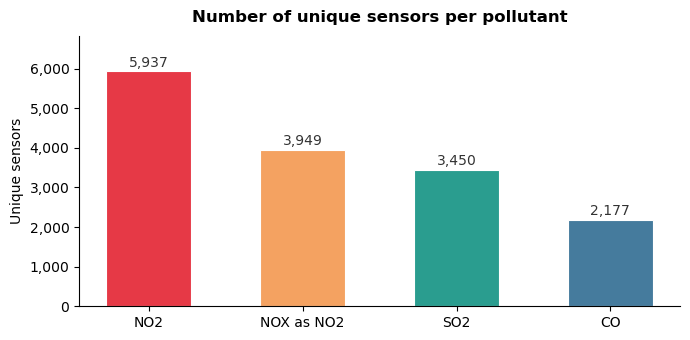

In [10]:
poll_counts = (
    sensor_pollutant
    .groupby('Air Pollutant')['sensor_uid']
    .nunique()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 3.5))
colors  = [POLLUTANT_COLORS.get(p, '#888888') for p in poll_counts.index]
bars    = ax.bar(poll_counts.index, poll_counts.values,
                 color=colors, edgecolor='white', linewidth=0.8, width=0.55)

for bar, val in zip(bars, poll_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 40,
            f'{val:,}', ha='center', va='bottom', fontsize=10, color='#333333')

ax.set_ylabel('Unique sensors', fontsize=10)
ax.set_title('Number of unique sensors per pollutant', fontsize=12,
             fontweight='bold', pad=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(0, poll_counts.max() * 1.15)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', labelsize=10)

plt.tight_layout()
plt.show()

### 7.2 Top Countries by Sensor Count

Germany and Italy lead in absolute sensor count, partly due to their large
populations and federalised monitoring networks. The colour breakdown shows
which pollutants drive the coverage for each country.

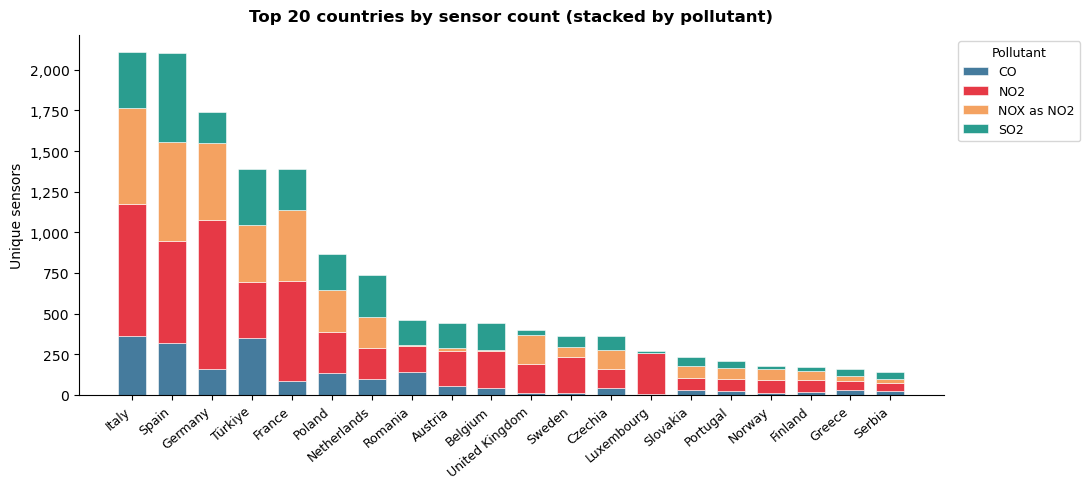

In [11]:
TOP_N = 20

# Sensors per country × pollutant (for stacked bars)
country_poll = (
    sensor_pollutant
    .groupby(['Country', 'Air Pollutant'])['sensor_uid']
    .nunique()
    .unstack(fill_value=0)
)

top_countries = (
    country_poll.sum(axis=1)
    .sort_values(ascending=False)
    .head(TOP_N)
    .index
)
country_poll_top = country_poll.loc[top_countries]

fig, ax = plt.subplots(figsize=(11, 5))

bottom = np.zeros(len(country_poll_top))
for pollutant in country_poll_top.columns:
    values = country_poll_top[pollutant].values
    ax.bar(
        country_poll_top.index, values,
        bottom=bottom,
        color=POLLUTANT_COLORS.get(pollutant, '#888888'),
        label=pollutant,
        edgecolor='white', linewidth=0.4, width=0.7
    )
    bottom += values

ax.set_ylabel('Unique sensors', fontsize=10)
ax.set_title(f'Top {TOP_N} countries by sensor count (stacked by pollutant)',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xticklabels(country_poll_top.index, rotation=40, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Pollutant', fontsize=9, title_fontsize=9,
          bbox_to_anchor=(1.01, 1), loc='upper left')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### 7.3 Geographic Distribution of Sensors

Each dot represents a unique sensor station coloured by pollutant type.
Dense clusters indicate highly monitored urban areas; sparse regions reflect
less populated or less industrialised areas with lighter monitoring requirements.

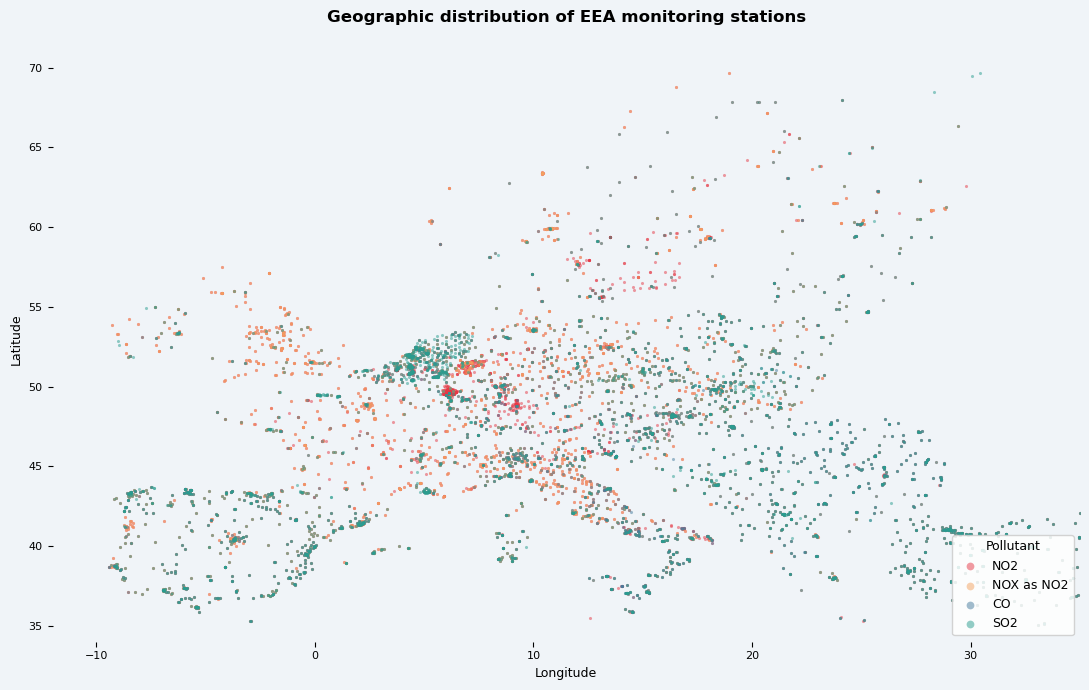

In [12]:
# One coordinate per sensor (take the first pollutant row arbitrarily)
geo = sensor_pollutant.drop_duplicates('sensor_uid')[['sensor_uid', 'Longitude', 'Latitude',
                                                        'Air Pollutant']].copy()

fig, ax = plt.subplots(figsize=(11, 7))
ax.set_facecolor('#f0f4f8')
fig.patch.set_facecolor('#f0f4f8')

for pollutant, color in POLLUTANT_COLORS.items():
    sub = sensor_pollutant[sensor_pollutant['Air Pollutant'] == pollutant]
    ax.scatter(
        sub['Longitude'], sub['Latitude'],
        c=color, s=5, alpha=0.5, linewidths=0,
        label=pollutant, rasterized=True
    )

# Rough bounding box for Europe
ax.set_xlim(-12, 35)
ax.set_ylim(34, 72)

ax.set_xlabel('Longitude', fontsize=9)
ax.set_ylabel('Latitude', fontsize=9)
ax.set_title('Geographic distribution of EEA monitoring stations',
             fontsize=12, fontweight='bold', pad=10)

legend = ax.legend(
    title='Pollutant', fontsize=9, title_fontsize=9,
    markerscale=2.5, framealpha=0.85,
    loc='lower right'
)

ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)
ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

### 7.5 Pollutant Coverage per Country

The heatmap shows, for each country, how many sensors measure each pollutant.
Countries that are completely white for a given pollutant have no monitoring data
for that species in this dataset.

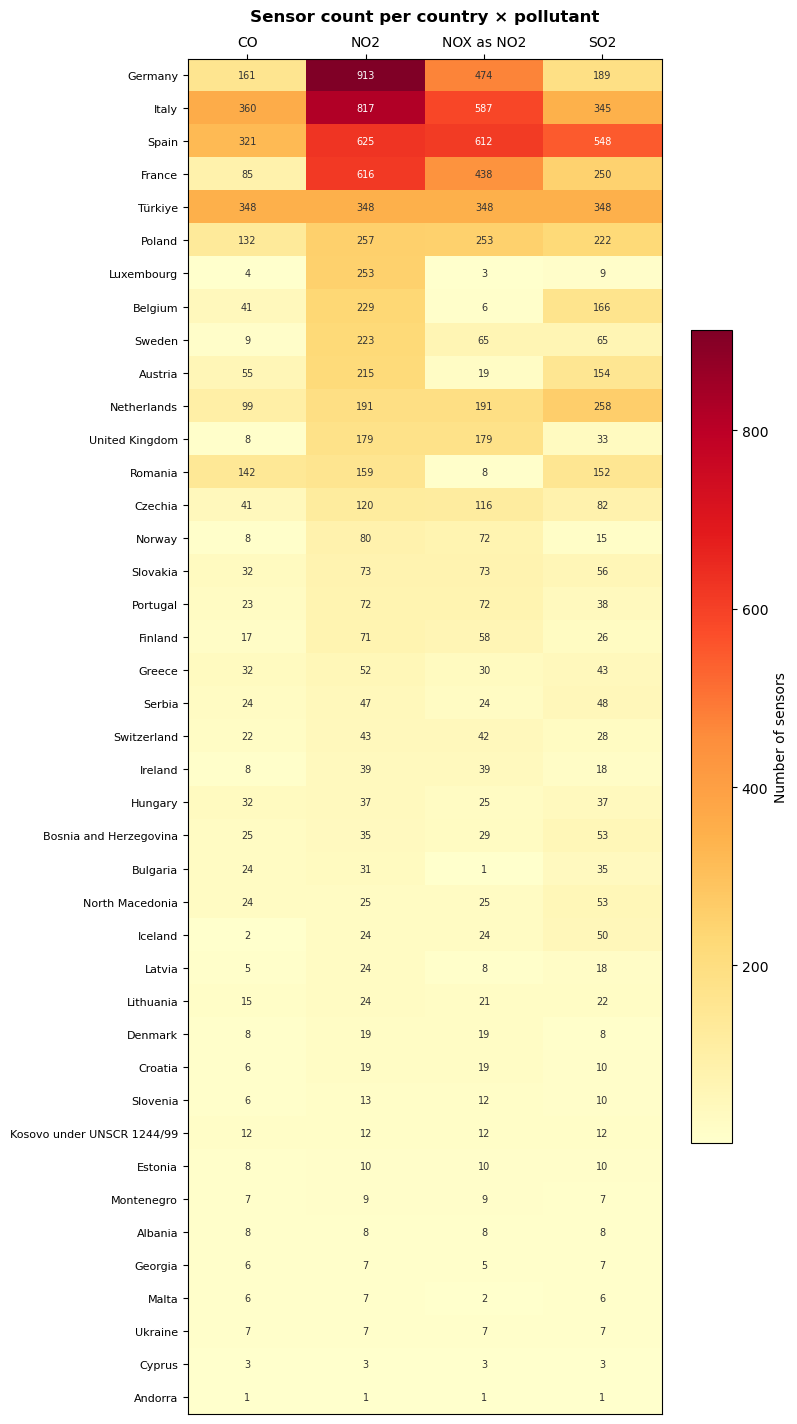

In [13]:
heatmap_data = (
    sensor_pollutant
    .groupby(['Country', 'Air Pollutant'])['sensor_uid']
    .nunique()
    .unstack(fill_value=0)
    .sort_values('NO2', ascending=False)  # sort by NO2 coverage
)

fig, ax = plt.subplots(figsize=(8, max(6, len(heatmap_data) * 0.35)))

im = ax.imshow(heatmap_data.values, aspect='auto', cmap='YlOrRd')

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, fontsize=10)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=8)

# Annotate each cell with the count
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        if val > 0:
            text_color = 'white' if val > heatmap_data.values.max() * 0.55 else '#333333'
            ax.text(j, i, str(val), ha='center', va='center',
                    fontsize=7, color=text_color)

plt.colorbar(im, ax=ax, label='Number of sensors', shrink=0.6)
ax.set_title('Sensor count per country × pollutant', fontsize=12,
             fontweight='bold', pad=10)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

plt.tight_layout()
plt.show()